## Introduction

## Preparation

In [49]:
# Import libraries
import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt
import seaborn           as sns
from scipy import stats  as st
from statsmodels.stats.proportion import proportions_ztest

from sklearn.model_selection  import StratifiedKFold, train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import roc_auc_score, roc_curve, recall_score, f1_score, accuracy_score, precision_score, confusion_matrix
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree             import DecisionTreeClassifier

In [50]:
# Download dataset
# path = "mdmahfuzsumon/large-scale-financial-fraud-dataset"
path = r"C:\Users\Pablo\Documents\Data_projects\2604_predictive_model_financial_fraud\improved_fraud_dataset.csv"
df = pd.read_csv(path)

In [51]:
# Visualize dataframe information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   organization           1000000 non-null  object 
 1   transaction_id         1000000 non-null  object 
 2   user_id                1000000 non-null  object 
 3   user_account_age_days  1000000 non-null  int64  
 4   kyc_verified           1000000 non-null  int64  
 5   payment_method         1000000 non-null  object 
 6   card_type              1000000 non-null  object 
 7   transaction_amount     1000000 non-null  float64
 8   currency               1000000 non-null  object 
 9   fee_amount             1000000 non-null  float64
 10  transaction_timestamp  1000000 non-null  object 
 11  day_of_week            1000000 non-null  object 
 12  city                   1000000 non-null  object 
 13  country                1000000 non-null  object 
 14  device_type        

In [52]:
# Show dataframe shape
print(f"Loaded Dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded Dataset: 1000000 rows, 24 columns


In [53]:
# Show dataframe first rows
print(df.head(3))

     organization transaction_id               user_id  user_account_age_days  \
0  FinovaTech_000    TXN00000044  FinovaTech_000_U0000                   1670   
1  FinovaTech_000    TXN00000004  FinovaTech_000_U0000                   1670   
2  FinovaTech_000    TXN00000033  FinovaTech_000_U0000                   1670   

   kyc_verified payment_method card_type  transaction_amount currency  \
0             1          bkash     debit             1553.81      BDT   
1             1          bkash     debit              136.49      BDT   
2             1           card    credit             3432.40      BDT   

   fee_amount  ... device_type operating_system browser merchant_category  \
0       31.08  ...      mobile          Windows  Safari           fashion   
1        2.73  ...     desktop          Android    Edge           grocery   
2       68.65  ...      tablet              iOS  Safari       electronics   

  transaction_type otp_used is_fraud hour is_night  time_diff  
0        

In [54]:
# Show dataframe last rows
print(df.tail(3))

          organization transaction_id               user_id  \
999997  FinovaTech_199    TXN00999984  FinovaTech_199_U0099   
999998  FinovaTech_199    TXN00999998  FinovaTech_199_U0099   
999999  FinovaTech_199    TXN00999972  FinovaTech_199_U0099   

        user_account_age_days  kyc_verified payment_method card_type  \
999997                    303             0           bank     debit   
999998                    303             1           bank    credit   
999999                    303             1          bkash    credit   

        transaction_amount currency  fee_amount  ... device_type  \
999997              234.90      BDT        4.70  ...      mobile   
999998             1104.45      BDT       22.09  ...     desktop   
999999              714.08      BDT       14.28  ...      mobile   

       operating_system browser merchant_category transaction_type otp_used  \
999997              iOS  Safari           fashion         purchase        0   
999998          Windows  Ch

In [55]:
print(df)

          organization transaction_id               user_id  \
0       FinovaTech_000    TXN00000044  FinovaTech_000_U0000   
1       FinovaTech_000    TXN00000004  FinovaTech_000_U0000   
2       FinovaTech_000    TXN00000033  FinovaTech_000_U0000   
3       FinovaTech_000    TXN00000050  FinovaTech_000_U0000   
4       FinovaTech_000    TXN00000047  FinovaTech_000_U0000   
...                ...            ...                   ...   
999995  FinovaTech_199    TXN00999994  FinovaTech_199_U0099   
999996  FinovaTech_199    TXN00999962  FinovaTech_199_U0099   
999997  FinovaTech_199    TXN00999984  FinovaTech_199_U0099   
999998  FinovaTech_199    TXN00999998  FinovaTech_199_U0099   
999999  FinovaTech_199    TXN00999972  FinovaTech_199_U0099   

        user_account_age_days  kyc_verified payment_method card_type  \
0                        1670             1          bkash     debit   
1                        1670             1          bkash     debit   
2                        16

In [56]:
print(df['transaction_timestamp'].head())

0    2024-01-26 08:20:20
1    2024-02-15 06:00:28
2    2024-02-24 19:47:58
3    2024-03-07 19:30:22
4    2024-03-12 12:58:07
Name: transaction_timestamp, dtype: object


## Data cleaning

In [57]:
# ========================
# Cleaning headers
# ========================
print(df.columns)

Index(['organization', 'transaction_id', 'user_id', 'user_account_age_days',
       'kyc_verified', 'payment_method', 'card_type', 'transaction_amount',
       'currency', 'fee_amount', 'transaction_timestamp', 'day_of_week',
       'city', 'country', 'device_type', 'operating_system', 'browser',
       'merchant_category', 'transaction_type', 'otp_used', 'is_fraud', 'hour',
       'is_night', 'time_diff'],
      dtype='object')


In [58]:
# ===================================
# Cleaning numerical columns
# ===================================
numeric = ['user_account_age_days', 'transaction_amount', 'fee_amount', 'hour', 'time_diff']
print(df[numeric].head(3))

   user_account_age_days  transaction_amount  fee_amount  hour  time_diff
0                   1670             1553.81       31.08     8        0.0
1                   1670              136.49        2.73     6  1719608.0
2                   1670             3432.40       68.65    19   827250.0


- Headers and numerical columns are clean

In [59]:
# =====================================
# Cleaning categorial typos
# =====================================

categorical = ['organization', 'transaction_id', 'user_id', 'payment_method', 'card_type', 'currency', 'day_of_week','city', 'country', 'device_type', 'operating_system', 'browser',
       'merchant_category', 'transaction_type']
# Verify that there are no duplicates in the categorical columns
print(f"There are {df[categorical].duplicated().sum()} duplicates.")
print()

for col in df[categorical]:
    print(col)
    print(df[col].unique())
    print()


There are 0 duplicates.

organization
['FinovaTech_000' 'FinovaTech_001' 'FinovaTech_002' 'FinovaTech_003'
 'FinovaTech_004' 'FinovaTech_005' 'FinovaTech_006' 'FinovaTech_007'
 'FinovaTech_008' 'FinovaTech_009' 'FinovaTech_010' 'FinovaTech_011'
 'FinovaTech_012' 'FinovaTech_013' 'FinovaTech_014' 'FinovaTech_015'
 'FinovaTech_016' 'FinovaTech_017' 'FinovaTech_018' 'FinovaTech_019'
 'FinovaTech_020' 'FinovaTech_021' 'FinovaTech_022' 'FinovaTech_023'
 'FinovaTech_024' 'FinovaTech_025' 'FinovaTech_026' 'FinovaTech_027'
 'FinovaTech_028' 'FinovaTech_029' 'FinovaTech_030' 'FinovaTech_031'
 'FinovaTech_032' 'FinovaTech_033' 'FinovaTech_034' 'FinovaTech_035'
 'FinovaTech_036' 'FinovaTech_037' 'FinovaTech_038' 'FinovaTech_039'
 'FinovaTech_040' 'FinovaTech_041' 'FinovaTech_042' 'FinovaTech_043'
 'FinovaTech_044' 'FinovaTech_045' 'FinovaTech_046' 'FinovaTech_047'
 'FinovaTech_048' 'FinovaTech_049' 'FinovaTech_050' 'FinovaTech_051'
 'FinovaTech_052' 'FinovaTech_053' 'FinovaTech_054' 'FinovaTech_0

In [60]:
# =====================================
# Cleaning booleans
# =====================================

# Verify that there are no mixed booleans columns
booleans = df[['kyc_verified', 'otp_used', 'is_fraud', 'is_night']]

for col in booleans:
    print(col)
    print(booleans[col].unique())
    print()

kyc_verified
[1 0]

otp_used
[1 0]

is_fraud
[0 1]

is_night
[0 1]



In [61]:
# =====================================
# Date parsing
# =====================================

# Check the type
print(df['transaction_timestamp'].dtype)

# Change of column type for date
df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'], yearfirst=True,errors='coerce')

print()
print("Fix applied")
print(df['transaction_timestamp'].dtype)

object

Fix applied
datetime64[ns]


## Exploratory Data Analysis

is_fraud
0    908290
1     91710
Name: is_fraud, dtype: int64



C:\Users\Pablo\AppData\Local\Temp\ipykernel_22324\566693496.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


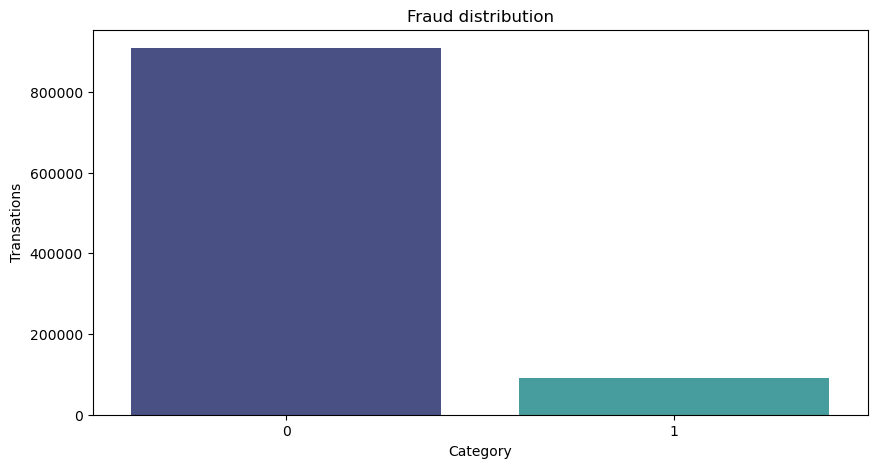

In [62]:
print(df.groupby(['is_fraud'])['is_fraud'].count())
print()
# Plot fraud distribution
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='is_fraud',
    palette="mako"
)

plt.title("Fraud distribution")
plt.xlabel("Category")
plt.ylabel("Transations")
plt.show()

### Fraud vs Numerical features

In [63]:
fraud_mean_amount = df.groupby(['is_fraud'])['transaction_amount'].mean()

print(fraud_mean_amount)

is_fraud
0    2001.396134
1    2022.402542
Name: transaction_amount, dtype: float64


In [64]:
fraud_mean_time_diff = df.groupby(['is_fraud'])['time_diff'].mean()

print(fraud_mean_time_diff)

is_fraud
0    1.220210e+06
1    1.167106e+06
Name: time_diff, dtype: float64


In [65]:
fraud_mean_account_long = df.groupby(['is_fraud'])['user_account_age_days'].mean()

print(fraud_mean_account_long)

is_fraud
0    1004.989733
1    1006.694199
Name: user_account_age_days, dtype: float64


In [66]:
print(df[['transaction_amount', 'time_diff', 'user_account_age_days']].describe())

       transaction_amount     time_diff  user_account_age_days
count      1000000.000000  1.000000e+06         1000000.000000
mean          2003.322631  1.215340e+06            1005.146050
std           2002.068308  1.216405e+06             575.471438
min              0.000000  0.000000e+00              10.000000
25%            578.357500  3.374908e+05             507.000000
50%           1388.160000  8.458925e+05            1006.000000
75%           2775.942500  1.703583e+06            1508.000000
max          31083.800000  1.766155e+07            2000.000000


### Fraud vs Categorical features

In [67]:
pmethod_count = df.groupby(['payment_method'])['payment_method'].count()
fraud_count_pmethod = df[df['is_fraud'] == 1].groupby(['payment_method'])['payment_method'].count()

print(pmethod_count)
print(fraud_count_pmethod)
print(fraud_count_pmethod / pmethod_count, 'Fraud rate by payment method')


payment_method
bank     249994
bkash    250147
card     249885
nagad    249974
Name: payment_method, dtype: int64
payment_method
bank     22797
bkash    23010
card     23057
nagad    22846
Name: payment_method, dtype: int64
payment_method
bank     0.091190
bkash    0.091986
card     0.092270
nagad    0.091394
Name: payment_method, dtype: float64 Fraud rate by payment method


In [68]:
fraud_count_card = df[df['is_fraud'] == 1].groupby(['card_type'])['card_type'].count().sort_values(ascending=False)

print(fraud_count_card)

card_type
debit     46037
credit    45673
Name: card_type, dtype: int64


In [69]:
fraud_count_device = df[df['is_fraud'] == 1].groupby(['device_type'])['device_type'].count().sort_values(ascending=False)

print(fraud_count_device)

device_type
tablet     30615
desktop    30573
mobile     30522
Name: device_type, dtype: int64


In [70]:
fraud_count_merchant = df[df['is_fraud'] == 1].groupby(['merchant_category'])['merchant_category'].count().sort_values(ascending=False)

print(fraud_count_merchant)

merchant_category
fashion        23070
grocery        23064
travel         23046
electronics    22530
Name: merchant_category, dtype: int64


In [71]:
fraud_count_transaction = df[df['is_fraud'] == 1].groupby(['transaction_type'])['transaction_type'].count().sort_values(ascending=False)

print(fraud_count_transaction)

transaction_type
withdrawal    30596
purchase      30577
transfer      30537
Name: transaction_type, dtype: int64


In [72]:
fraud_count_city = df[df['is_fraud'] == 1].groupby(['city'])['city'].count().sort_values(ascending=False)

print(fraud_count_city)

city
Chittagong    23077
Rajshahi      22970
Dhaka         22895
Khulna        22768
Name: city, dtype: int64


In [73]:
day = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fraud_count_day = df[df['is_fraud'] == 1].groupby(['day_of_week'])['day_of_week'].count().reindex(day)

print(fraud_count_day)

day_of_week
Monday       13185
Tuesday      13272
Wednesday    13229
Thursday     13217
Friday       13055
Saturday     12739
Sunday       13013
Name: day_of_week, dtype: int64


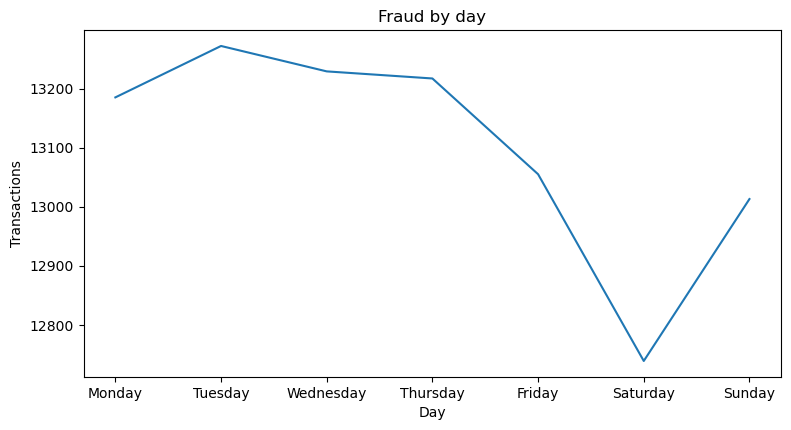

In [74]:
# Plot fraud by day
plt.figure(figsize=(9,4.5))

sns.lineplot(x=fraud_count_day.index,
             y=fraud_count_day.values            
)

plt.title("Fraud by day")
plt.xlabel('Day')
plt.ylabel('Transactions')
plt.show()

In [75]:
fraud_count_opsystem = df[df['is_fraud'] == 1].groupby(['operating_system'])['operating_system'].count().sort_values(ascending=False)

print(fraud_count_opsystem)

operating_system
Windows    30739
iOS        30677
Android    30294
Name: operating_system, dtype: int64


In [76]:
fraud_count_browser = df[df['is_fraud'] == 1].groupby(['browser'])['browser'].count().sort_values(ascending=False)

print(fraud_count_browser)

browser
Chrome    30617
Edge      30570
Safari    30523
Name: browser, dtype: int64


### Fraud vs Boolean Features

What is the probability of fraud occurring on an account with KYC?

In [77]:
kyc_count = df.groupby(['kyc_verified'])['kyc_verified'].count()
fraud_count_kyc = df[df['is_fraud'] == 1].groupby(['kyc_verified'])['kyc_verified'].count()

print(kyc_count, 'Total with and without kyc verified')
print(fraud_count_kyc, 'Fraud with and without kyc verified')
print(fraud_count_kyc / kyc_count, 'Fraud rate with and without kyc verfied')

kyc_verified
0    199615
1    800385
Name: kyc_verified, dtype: int64 Total with and without kyc verified
kyc_verified
0    18413
1    73297
Name: kyc_verified, dtype: int64 Fraud with and without kyc verified
kyc_verified
0    0.092243
1    0.091577
Name: kyc_verified, dtype: float64 Fraud rate with and without kyc verfied


**Hipotesis**

H0: The fraud rate is **the same** with and without KYC.

H1: The fraud rate is **different** with and without KYC.

In [78]:
st, p_value = proportions_ztest(fraud_count_kyc, kyc_count)

print(f"Z-test: {st:.4f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("We reject H0 → the rates are significantly different")
else:
    print("We do not reject H0 → there is no significant difference")

Z-test: 0.9215
p-value: 0.3568
We do not reject H0 → there is no significant difference


What is the probability of fraud in an OTP transaction?

In [79]:
otp_count = df.groupby(['otp_used'])['otp_used'].count()
fraud_count_otp = df[df['is_fraud'] == 1].groupby(['otp_used'])['otp_used'].count()

print(otp_count, 'Total with and without otp used')
print(fraud_count_otp, 'Fraud with and without otp used')
print(fraud_count_otp / otp_count, 'Fraud rate with and without otp used')

otp_used
0    300557
1    699443
Name: otp_used, dtype: int64 Total with and without otp used
otp_used
0    27645
1    64065
Name: otp_used, dtype: int64 Fraud with and without otp used
otp_used
0    0.091979
1    0.091594
Name: otp_used, dtype: float64 Fraud rate with and without otp used


**Hipotesis**

H0: The fraud rate is **the same** with and without OTP.

H1: The fraud rate is **different** with and without OTP.

In [80]:
st, p_value = proportions_ztest(fraud_count_otp, otp_count)

print(f"Z-test: {st:.4f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("We reject H0 → the rates are significantly different")
else:
    print("We do not reject H0 → there is no significant difference")

Z-test: 0.6115
p-value: 0.5409
We do not reject H0 → there is no significant difference


What is the probability of fraud occurring at night?

In [81]:
is_night_count = df.groupby(['is_night'])['is_night'].count()
fraud_count_night = df[df['is_fraud'] == 1].groupby(['is_night'])['is_night'].count()

print(is_night_count, 'Total transactions at day and at night')
print(fraud_count_night, 'Fraud at day and at night')
print(fraud_count_night / is_night_count, 'Fraud rate at day and at night')

is_night
0    708478
1    291522
Name: is_night, dtype: int64 Total transactions at day and at night
is_night
0     4325
1    87385
Name: is_night, dtype: int64 Fraud at day and at night
is_night
0    0.006105
1    0.299754
Name: is_night, dtype: float64 Fraud rate at day and at night


**Hipotesis**

H0: The fraud rate is **the same** during the day and at night.

H1: The fraud rate is **different** during the day and at night.

In [82]:
st, p_value = proportions_ztest(fraud_count_night, is_night_count)

print(f"Z-test: {st:.4f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("We reject H0 → the rates are significantly different")
else:
    print("We do not reject H0 → there is no significant difference")

Z-test: -462.3894
p-value: 0.0000
We reject H0 → the rates are significantly different


### Fraud vs Time

In [83]:
fraud_vs_hour = df[df['is_fraud'] == 1].groupby(['hour'])['hour'].count()

print(fraud_vs_hour)

hour
0     12543
1     12598
2     12415
3     12419
4     12382
5     12476
6       262
7       235
8       241
9       276
10      247
11      251
12      224
13      252
14      280
15      280
16      238
17      259
18      252
19      251
20      268
21      278
22      231
23    12552
Name: hour, dtype: int64


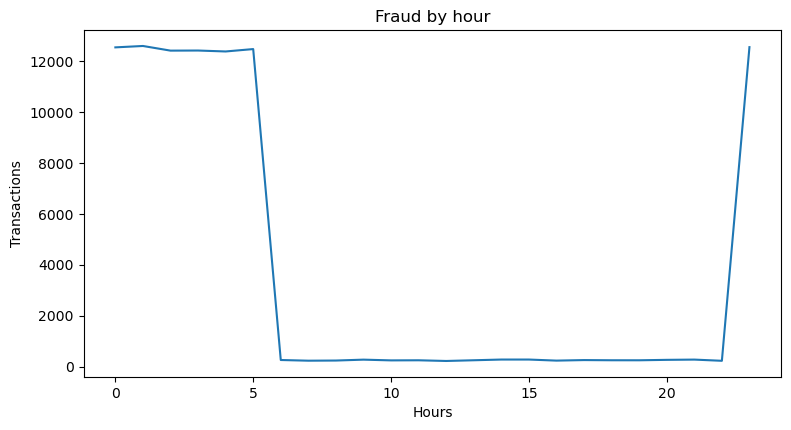

In [84]:
# Plot fraud by hour
plt.figure(figsize=(9,4.5))

sns.lineplot(x=fraud_vs_hour.index,
             y=fraud_vs_hour.values            
)

plt.title("Fraud by hour")
plt.xlabel('Hours')
plt.ylabel('Transactions')
plt.show()

## Modeling

In [85]:
# Drop irrelevant features
print(df.columns)
print()

df_new = df.drop(['organization', 'transaction_id', 'user_id', 'currency','transaction_timestamp', 'country'], axis=1, errors='ignore')
print(df_new.info())

Index(['organization', 'transaction_id', 'user_id', 'user_account_age_days',
       'kyc_verified', 'payment_method', 'card_type', 'transaction_amount',
       'currency', 'fee_amount', 'transaction_timestamp', 'day_of_week',
       'city', 'country', 'device_type', 'operating_system', 'browser',
       'merchant_category', 'transaction_type', 'otp_used', 'is_fraud', 'hour',
       'is_night', 'time_diff'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 18 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   user_account_age_days  1000000 non-null  int64  
 1   kyc_verified           1000000 non-null  int64  
 2   payment_method         1000000 non-null  object 
 3   card_type              1000000 non-null  object 
 4   transaction_amount     1000000 non-null  float64
 5   fee_amount             1000000 non-null  float64
 6   day_of_week      

In [86]:
numeric = ['user_account_age_days', 'transaction_amount', 'fee_amount', 'hour', 'time_diff']

In [87]:
categorical = ['payment_method', 'card_type', 'day_of_week','city', 'device_type', 
                  'operating_system', 'browser', 'merchant_category', 'transaction_type']

In [88]:
data_ohe = pd.get_dummies(df_new, columns=categorical, drop_first=True)
print(data_ohe.head(3))

   user_account_age_days  kyc_verified  transaction_amount  fee_amount  \
0                   1670             1             1553.81       31.08   
1                   1670             1              136.49        2.73   
2                   1670             1             3432.40       68.65   

   otp_used  is_fraud  hour  is_night  time_diff  payment_method_bkash  ...  \
0         1         0     8         0        0.0                  True  ...   
1         0         0     6         0  1719608.0                  True  ...   
2         1         0    19         0   827250.0                 False  ...   

   device_type_tablet  operating_system_Windows  operating_system_iOS  \
0               False                      True                 False   
1               False                     False                 False   
2                True                     False                  True   

   browser_Edge  browser_Safari  merchant_category_fashion  \
0         False            True

In [89]:
# Divide the features and the target
features = data_ohe.drop(['is_fraud'], axis=1)
target = data_ohe['is_fraud']

# Divide the data for training and validation
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.25, random_state=12345)

print(f'Train: {features_train.shape}')
print(f'Test: {features_test.shape}')

Train: (750000, 32)
Test: (250000, 32)


In [90]:
# ===============================
# Evaluation function
# ===============================

def evaluate_model(model, features_train, target_train, cv, model_name, param_name, param_value, scale=False):
    """
    Evaluate a model using cross validation.

    Parameters
    ----------
    model           : Sklearn model with hyperparameters wanted
    features_train  : features from training set
    target_train    : target from training set
    cv              : object StratifiedFold
    model_name      : Model name that will be printed
    param_name      : Hyperparameter that will be changing
    param_value     : Hyperparameter value
    scale           : Bool - if True aplply StandardScaler within the fold

    Return
    ----------
    dict with average metrics
    """
    # Header
    print(f"\n{model_name} ({param_name}: {param_value})")     
    print("="*65)

    # Empty lists for results
    acc_scores, prec_scores, rec_scores, f1_scores, auc_scores = [], [], [], [], []

    # Cross validation by fold
    for fold, (train_idx, val_idx) in enumerate(cv.split(features_train, target_train), 1):
        X_train = features_train.iloc[train_idx]
        X_val   = features_train.iloc[val_idx]
        y_train = target_train.iloc[train_idx]
        y_val   = target_train.iloc[val_idx]

        # Scale within the fold to prevent leakage
        if scale:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train) # Fit only train set
            X_val   = scaler.transform(X_val)       # Transform in validation
        
        # Train model
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        probs = np.array(model.predict_proba(X_val))[:, 1].ravel()

        # Metrics by iteration
        acc  = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds)
        rec  = recall_score(y_val, preds, zero_division=0)
        f1   = f1_score(y_val, preds, zero_division=0)
        auc  = roc_auc_score(y_val, probs)

        # Append results to lists
        acc_scores.append(acc)
        prec_scores.append(prec)
        rec_scores.append(rec)
        f1_scores.append(f1)
        auc_scores.append(auc)

        print(f"Fold {fold} | Acc: {acc:.3f} | Prec: {prec:.3f} | "
              f"Rec: {rec:.3f} | F1: {f1:.3f} | AUROC: {auc:.3f}")
    means = {
        'acc' : np.mean(acc_scores),
        'prec' : np.mean(prec_scores),
        'rec' : np.mean(rec_scores),
        'f1' : np.mean(f1_scores),
        'auc' : np.mean(auc_scores),
    }

    print(f"\n Average ({param_name}={param_value})")
    print(f"\n Accuracy  : {means['acc']:.4f}")
    print(f"\n Precision : {means['prec']:.4f}")
    print(f"\n Recall    : {means['rec']:.4f}")
    print(f"\n F1        : {means['f1']:.4f}")
    print(f"\n AU-ROC    : {means['auc']:.4f}")

    return means


In [91]:
# ===============================
# Best result function
# ===============================

def find_best(results, param_name):
    """
    Print best model measure by AU-ROC
    """
    best = max(results, key=lambda r: r['auc'])
    print("\n" + "="*65)
    print("\n Best setup:")
    print(f" {param_name} : {best[param_name]}")
    print(f" Mean Accuracy : {best['acc']:.4f}")
    print(f" Best AU-ROC : {best['auc']:.4f}")
    return best

In [92]:
# ===============================
# Cross validation
# ===============================

# Only features_train
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=12345)

In [93]:
# Logistic Regression
print("\n Logistic Regression ")

# Empty list for results
lr_results = []
# Bucle for hyperparameter
for iteration in [100,200]:
    # Define model
    model = LogisticRegression(
        random_state=12345,
        max_iter=iteration,
        solver='lbfgs'
    )
    means = evaluate_model(
        model, features_train, target_train, cv, model_name="LogisticRegression", param_name="max_iter",
        param_value=iteration, scale=True
    )
    # Select results of hyperparameter
    means['max_iter'] = iteration
    # Gather results
    lr_results.append(means)

best_lr = find_best(lr_results, 'max_iter')


 Logistic Regression 

LogisticRegression (max_iter: 100)


c:\Users\Pablo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 1 | Acc: 0.908 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | AUROC: 0.874


c:\Users\Pablo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 2 | Acc: 0.908 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | AUROC: 0.875


...

Fold 3 | Acc: 0.908 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | AUROC: 0.873


c:\Users\Pablo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 4 | Acc: 0.908 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | AUROC: 0.876


c:\Users\Pablo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 5 | Acc: 0.908 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | AUROC: 0.875

 Average (max_iter=200)

 Accuracy  : 0.9084

 Precision : 0.0000

 Recall    : 0.0000

 F1        : 0.0000

 AU-ROC    : 0.8745


 Best setup:
 max_iter : 100
 Mean Accuracy : 0.9084
 Best AU-ROC : 0.8745


In [94]:
# Decision Tree
print("\n Decision Tree ")

# Empty list for results
tree_results = []
# Bucle for hyperparameter
for depth in [6,7,8]:
    # Define model
    model = DecisionTreeClassifier(
        random_state=12345,
        max_depth=depth
    )
    # Evaluate model
    means = evaluate_model(
        model, features_train, target_train, cv, model_name="DecisionTreeClassifier", param_name="max_depth",
        param_value=depth, scale=False
    )
    # Select results of hyperparameter
    means['max_depth'] = depth
    # Gather results
    tree_results.append(means)

best_tree = find_best(tree_results, 'max_depth')


 Decision Tree 

DecisionTreeClassifier (max_depth: 6)
Fold 1 | Acc: 0.908 | Prec: 0.244 | Rec: 0.001 | F1: 0.002 | AUROC: 0.883
Fold 2 | Acc: 0.908 | Prec: 0.304 | Rec: 0.001 | F1: 0.001 | AUROC: 0.882
Fold 3 | Acc: 0.908 | Prec: 0.300 | Rec: 0.001 | F1: 0.003 | AUROC: 0.882
Fold 4 | Acc: 0.908 | Prec: 0.333 | Rec: 0.000 | F1: 0.001 | AUROC: 0.884
Fold 5 | Acc: 0.908 | Prec: 0.217 | Rec: 0.000 | F1: 0.001 | AUROC: 0.883

 Average (max_depth=6)

 Accuracy  : 0.9083

 Precision : 0.2799

 Recall    : 0.0007

 F1        : 0.0014

 AU-ROC    : 0.8829

DecisionTreeClassifier (max_depth: 7)
Fold 1 | Acc: 0.908 | Prec: 0.287 | Rec: 0.002 | F1: 0.003 | AUROC: 0.882
Fold 2 | Acc: 0.908 | Prec: 0.196 | Rec: 0.001 | F1: 0.001 | AUROC: 0.882
Fold 3 | Acc: 0.908 | Prec: 0.264 | Rec: 0.001 | F1: 0.003 | AUROC: 0.881
Fold 4 | Acc: 0.908 | Prec: 0.404 | Rec: 0.002 | F1: 0.003 | AUROC: 0.884
Fold 5 | Acc: 0.908 | Prec: 0.255 | Rec: 0.001 | F1: 0.002 | AUROC: 0.883

 Average (max_depth=7)

 Accuracy  

In [95]:
# Random Forest
print("\n Random Forest ")

# Empty list for results
forest_results = []
# Bucle for hyperparameter
for estimators in [50,100,150]:
    # Define model
    model = RandomForestClassifier(
        random_state=12345,
        max_depth = best_tree['max_depth'],
        n_estimators=estimators
    )
    # Evaluate model
    means = evaluate_model(
        model, features_train, target_train, cv, model_name="RandomForestClassifier", param_name="n_estimators",
        param_value=estimators, scale=False
    )
    # Select results of hyperparameter
    means['n_estimators'] = estimators
    # Gather results
    forest_results.append(means)

best_forest = find_best(forest_results, 'n_estimators')


 Random Forest 

RandomForestClassifier (n_estimators: 50)


c:\Users\Pablo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 1 | Acc: 0.908 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | AUROC: 0.882


c:\Users\Pablo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 2 | Acc: 0.908 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | AUROC: 0.880


...

Fold 3 | Acc: 0.908 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | AUROC: 0.881


c:\Users\Pablo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 4 | Acc: 0.908 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | AUROC: 0.882


c:\Users\Pablo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 5 | Acc: 0.908 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | AUROC: 0.883

 Average (n_estimators=150)

 Accuracy  : 0.9084

 Precision : 0.0000

 Recall    : 0.0000

 F1        : 0.0000

 AU-ROC    : 0.8815


 Best setup:
 n_estimators : 50
 Mean Accuracy : 0.9084
 Best AU-ROC : 0.8818


In [96]:
# Gradient Boosting
print("\n Gradient Boosting ")

# Empty list for results
gboost_results = []
# Bucle for hyperparameter
for estimators in [50,100,150]:
    # Define model
    model = GradientBoostingClassifier(
        random_state=12345,
        max_depth = 4,
        n_estimators=estimators,
        learning_rate=0.1,
        loss='log_loss'
    )
    # Evaluate model
    means = evaluate_model(
        model, features_train, target_train, cv, model_name="GradientBoostingClassifier", param_name="n_estimators",
        param_value=estimators, scale=False
    )
    # Select results of hyperparameter
    means['n_estimators'] = estimators
    # Gather results
    gboost_results.append(means)

best_gboost = find_best(gboost_results, 'n_estimators')


 Gradient Boosting 

GradientBoostingClassifier (n_estimators: 50)
Fold 1 | Acc: 0.908 | Prec: 0.333 | Rec: 0.000 | F1: 0.000 | AUROC: 0.882
Fold 2 | Acc: 0.908 | Prec: 0.667 | Rec: 0.000 | F1: 0.001 | AUROC: 0.882
Fold 3 | Acc: 0.908 | Prec: 0.375 | Rec: 0.000 | F1: 0.000 | AUROC: 0.881
Fold 4 | Acc: 0.908 | Prec: 0.364 | Rec: 0.000 | F1: 0.001 | AUROC: 0.884
Fold 5 | Acc: 0.908 | Prec: 0.429 | Rec: 0.000 | F1: 0.000 | AUROC: 0.882

 Average (n_estimators=50)

 Accuracy  : 0.9084

 Precision : 0.4334

 Recall    : 0.0003

 F1        : 0.0005

 AU-ROC    : 0.8824

GradientBoostingClassifier (n_estimators: 100)
Fold 1 | Acc: 0.908 | Prec: 0.067 | Rec: 0.000 | F1: 0.000 | AUROC: 0.883
Fold 2 | Acc: 0.908 | Prec: 0.368 | Rec: 0.001 | F1: 0.001 | AUROC: 0.882
Fold 3 | Acc: 0.908 | Prec: 0.462 | Rec: 0.000 | F1: 0.001 | AUROC: 0.881


KeyboardInterrupt: 

In [ ]:
# ===============================
# Comparison between models
# ===============================

print("\n\n" + "=" * 65)
print("Comparison Summary (AU-ROC with cross validation)")
print("=" * 65)
 
summary = [
    ("Logistic Regression", best_lr),
    ("Decision Tree",       best_tree),
    ("Random Forest",       best_forest),
    ("Gradient Boosting",   best_gboost),
]
 
for name, result in sorted(summary, key=lambda x: x[1]['auc'], reverse=True):
    print(f"  {name:<25} AU-ROC: {result['auc']:.4f} | F1: {result['f1']:.4f}")

## Conclusions